# 9. Bird vs Drone Image Classification

## 9.1 Import required dependencies and modules

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

In [ ]:
import random
import os
import shutil
import zipfile
import pathlib

## 9.2 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## 9.3 Download Dataset from Kaggle

In [ ]:
! pip install kaggle

In [ ]:
source = "/content/drive/MyDrive/kaggle.json"
destination = "/content/"

shutil.copy(src=source, dst=destination)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/kaggle.json'

In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download harshwalia/birds-vs-drone-dataset

In [ ]:
# Unzip the downloaded file
zip_ref = zipfile.ZipFile("birds-vs-drone-dataset.zip")
zip_ref.extractall()
zip_ref.close()

## 9.4 Split the dataset into training and test sets

In [ ]:
def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    file_names = os.listdir(SOURCE)
    random_file_names = random.sample(file_names, len(file_names))
    split_threshold = round(SPLIT_SIZE * len(random_file_names))
    for item in random_file_names[:split_threshold]:
        if os.path.getsize(os.path.join(SOURCE,item)) == 0:
            print(f"{item} is zero length, so ignoring.")
        else:
            shutil.copy(os.path.join(SOURCE,item),TRAINING)
    for item in random_file_names[split_threshold:len(random_file_names)]:
        if os.path.getsize(os.path.join(SOURCE,item)) == 0:
            print(f"{item} is zero length, so ignoring.")
        else:
            shutil.copy(os.path.join(SOURCE,item),TESTING)

In [ ]:
DRONE_SOURCE_DIR = "/content/BirdVsDrone/Drones"
BIRD_SOURCE_DIR = "/content/BirdVsDrone/Birds"

TRAINING_DIR = '/content/BirdVsDroneSplit/train/'
TESTING_DIR = '/content/BirdVsDroneSplit/test/'

TRAINING_DRONE_DIR = TRAINING_DIR + "drones/"
TESTING_DRONE_DIR = TESTING_DIR + "drones/"

TRAINING_BIRD_DIR = TRAINING_DIR + "birds/"
TESTING_BIRD_DIR = TESTING_DIR + "birds/"

In [ ]:
try:
  os.makedirs(TRAINING_BIRD_DIR)
  os.makedirs(TESTING_BIRD_DIR)
  os.makedirs(TRAINING_DRONE_DIR)
  os.makedirs(TESTING_DRONE_DIR)
except:
  pass

In [ ]:
split_size = 0.8

split_data(DRONE_SOURCE_DIR, TRAINING_DRONE_DIR, TESTING_DRONE_DIR, split_size)
split_data(BIRD_SOURCE_DIR, TRAINING_BIRD_DIR, TESTING_BIRD_DIR, split_size)

## 9.5 Load the split dataset from Google Drive

In [ ]:
dataset_path = "/content/drive/MyDrive/BirdVsDroneSplit"

for dirpath, dirnames, filenames in os.walk(dataset_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 3 directories and 0 images in '/content/drive/MyDrive/BirdVsDroneSplit'.
There are 2 directories and 0 images in '/content/drive/MyDrive/BirdVsDroneSplit/Val'.
There are 0 directories and 50 images in '/content/drive/MyDrive/BirdVsDroneSplit/Val/Bird'.
There are 0 directories and 60 images in '/content/drive/MyDrive/BirdVsDroneSplit/Val/Drone'.
There are 2 directories and 0 images in '/content/drive/MyDrive/BirdVsDroneSplit/test'.
There are 0 directories and 50 images in '/content/drive/MyDrive/BirdVsDroneSplit/test/Bird'.
There are 0 directories and 60 images in '/content/drive/MyDrive/BirdVsDroneSplit/test/Drone'.
There are 2 directories and 0 images in '/content/drive/MyDrive/BirdVsDroneSplit/train'.
There are 0 directories and 308 images in '/content/drive/MyDrive/BirdVsDroneSplit/train/drones'.
There are 0 directories and 300 images in '/content/drive/MyDrive/BirdVsDroneSplit/train/birds'.


In [ ]:
# Get the class names programmatically
data_dir = pathlib.Path(dataset_path + "/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirectories
print(class_names)

['birds' 'drones']


## 9.6 Visualize random images from dataset

In [ ]:
# Let's visualize our images
import matplotlib.image as mpimg

def view_random_image(target_dir, target_class):
    # Setup the target directory (we'll view images from here)
    target_folder = target_dir + target_class

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)

    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");

    print(f"Image shape: {img.shape}") # show the shape of the image

    return img

['singleBirdinsky84.jpeg']
Image shape: (183, 275, 3)


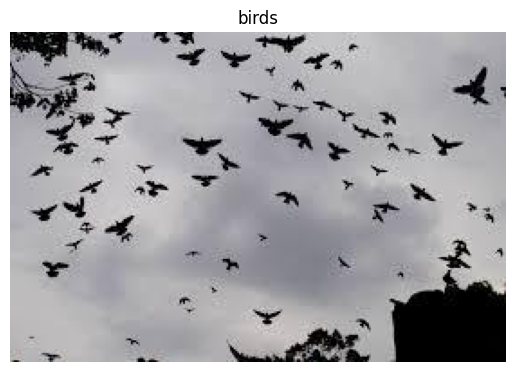

In [ ]:
# View a random image from the training dataset
img = view_random_image(target_dir=dataset_path + "/train/",
                        target_class="birds")

['229.JPEG']
Image shape: (1090, 1920, 3)


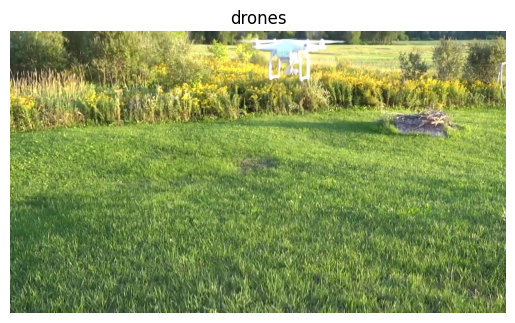

In [ ]:
# View a random image from the training dataset
img = view_random_image(target_dir=dataset_path + "/train/",
                        target_class="drones")

## 9.7 Prepare the dataset to feed into the neural network

In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255.0)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [ ]:
train_dir = dataset_path + "/train/"
test_dir = dataset_path + "/test/"

In [ ]:
train_data = train_datagen.flow_from_directory(directory=train_dir,     # Target directory of images
                                               target_size=(224, 224),  # Target size of images (height, width)
                                               class_mode="binary",     # Type of data you're working with
                                               batch_size=32,           # Size of minibatches to load data into
                                               shuffle=True)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             batch_size=32,
                                             shuffle=True)

Found 606 images belonging to 2 classes.
Found 110 images belonging to 2 classes.


In [ ]:
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,        # how much do you want to rotate an image?
                                             shear_range=0.2,           # how much do you want to shear an image?
                                             zoom_range=0.2,            # zoom in randomly on an image
                                             width_shift_range=0.2,     # move your image around on the x-axis
                                             height_shift_range=0.2,    # move your image around on the y-axis
                                             horizontal_flip=True)      # do you want to flip an image?

In [ ]:
train_data_augmented = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                   target_size=(224, 224),
                                                                   class_mode="binary",
                                                                   batch_size=32)

Found 606 images belonging to 2 classes.


In [ ]:
saved_models_path = "/content/drive/MyDrive/saved_models/"

## 9.8 Define helper functions

In [ ]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))    # how many epochs did we run for?

    # Plot loss
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
    """
    Reads an image from filename, turns it into a tensor and reshapes it
    to (img_shape, img_shape, colour_channels).
    """
    # Read in the image
    img = tf.io.read_file(filename)

    # Decode the read file into a tensor
    img = tf.image.decode_image(img)

    # Resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])

    # Rescale the image (get all values between 0 and 1)
    img = img / 255.

    return img

In [ ]:
def pred_and_plot(model, filename, class_names=class_names):
    """
    Imports an image located at filename, makes a prediction with model
    and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    img = load_and_prep_image(filename)

    # Make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))
    print(pred)

    # Get the predicted class
    pred_class = class_names[int(tf.round(pred))]

    # Plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

In [ ]:
def pred_and_plot_directory(model, directory, class_names=class_names):
    """
    Imports an image located at directory, makes a prediction with model
    and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    plt.figure(figsize=(12, 12))
    i = 1
    for filename in os.listdir(directory):
        img = load_and_prep_image(directory + "/" + filename)

        # Make a prediction
        pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)
        prob = pred[0][0]
        # print(pred)

        # Get the predicted class
        pred_class = class_names[int(tf.round(pred))]

        # Calculate probability if pred_class is bird
        if pred_class == 'birds':
            prob = 1 - prob

        # Plot the image and predicted class
        plt.subplot(2, 2, i)
        plt.imshow(img)
        plt.title("Prediction: {}\nProbability: {:.4f}".format(pred_class, prob))
        plt.axis(False);
        i += 1

In [ ]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

## 9.9 Create the model, Compile the model and Fit the model

Epoch 1/110
19/19 [==============================] - ETA: 0s - loss: 0.7279 - accuracy: 0.6419

19/19 [==============================] - 98s 5s/step - loss: 0.7279 - accuracy: 0.6419 - val_loss: 0.5968 - val_accuracy: 0.6182
Epoch 2/110
19/19 [==============================] - ETA: 0s - loss: 0.5282 - accuracy: 0.7079

19/19 [==============================] - 21s 1s/step - loss: 0.5282 - accuracy: 0.7079 - val_loss: 0.7909 - val_accuracy: 0.6727
Epoch 3/110
19/19 [==============================] - ETA: 0s - loss: 0.4836 - accuracy: 0.7987

19/19 [==============================] - 21s 1s/step - loss: 0.4836 - accuracy: 0.7987 - val_loss: 0.5501 - val_accuracy: 0.7545
Epoch 4/110
19/19 [==============================] - 18s 960ms/step - loss: 0.4108 - accuracy: 0.8251 - val_loss: 0.5337 - val_accuracy: 0.7455
Epoch 5/110
19/19 [==============================] - ETA: 0s - loss: 0.3837 - accuracy: 0.8333

19/19 [==============================] - 20s 1s/step - loss: 0.3837 - accuracy: 0.8333 - val_loss: 0.4645 - val_accuracy: 0.7909
Epoch 6/110
19/19 [==============================] - ETA: 0s - loss: 0.3513 - accuracy: 0.8317

19/19 [==============================] - 20s 1s/step - loss: 0.3513 - accuracy: 0.8317 - val_loss: 0.4453 - val_accuracy: 0.8182
Epoch 7/110
19/19 [==============================] - 18s 973ms/step - loss: 0.3334 - accuracy: 0.8564 - val_loss: 0.4601 - val_accuracy: 0.8000
Epoch 8/110
19/19 [==============================] - 17s 896ms/step - loss: 0.3567 - accuracy: 0.8416 - val_loss: 0.4991 - val_accuracy: 0.8182
Epoch 9/110
19/19 [==============================] - 17s 923ms/step - loss: 0.3246 - accuracy: 0.8713 - val_loss: 0.4754 - val_accuracy: 0.7727
Epoch 10/110
19/19 [==============================] - 17s 895ms/step - loss: 0.3198 - accuracy: 0.8581 - val_loss: 0.4396 - val_accuracy: 0.8182
Epoch 11/110
19/19 [==============================] - 19s 990ms/step - loss: 0.3331 - accuracy: 0.8515 - val_loss: 0.4963 - val_accuracy: 0.7909
Epoch 12/110
19/19 [==============================] - 17s 900ms/step - loss: 0.2975 - accuracy: 0.8680 - val_loss: 0.4699 - val_accuracy: 0.7636
Epoc

19/19 [==============================] - 24s 1s/step - loss: 0.2591 - accuracy: 0.8729 - val_loss: 0.4413 - val_accuracy: 0.8273
Epoch 19/110
19/19 [==============================] - ETA: 0s - loss: 0.2481 - accuracy: 0.8960

19/19 [==============================] - 21s 1s/step - loss: 0.2481 - accuracy: 0.8960 - val_loss: 0.4686 - val_accuracy: 0.8364
Epoch 20/110
19/19 [==============================] - 20s 1s/step - loss: 0.2749 - accuracy: 0.8894 - val_loss: 0.4781 - val_accuracy: 0.8364
Epoch 21/110
19/19 [==============================] - 18s 925ms/step - loss: 0.2387 - accuracy: 0.8911 - val_loss: 0.4893 - val_accuracy: 0.8364
Epoch 22/110
19/19 [==============================] - 20s 1s/step - loss: 0.2858 - accuracy: 0.8828 - val_loss: 0.5545 - val_accuracy: 0.8182
Epoch 23/110
19/19 [==============================] - 19s 1s/step - loss: 0.2788 - accuracy: 0.8812 - val_loss: 0.6586 - val_accuracy: 0.7636
Epoch 24/110
19/19 [==============================] - 17s 911ms/step - loss: 0.2834 - accuracy: 0.8630 - val_loss: 0.4707 - val_accuracy: 0.7636
Epoch 25/110
19/19 [==============================] - 20s 1s/step - loss: 0.2572 - accuracy: 0.8960 - val_loss: 0.4631 - val_accuracy: 0.8182
Epoch 26/110


19/19 [==============================] - 19s 1s/step - loss: 0.2340 - accuracy: 0.8960 - val_loss: 0.4367 - val_accuracy: 0.8455
Epoch 28/110
19/19 [==============================] - 20s 1s/step - loss: 0.2239 - accuracy: 0.9059 - val_loss: 0.4857 - val_accuracy: 0.8000
Epoch 29/110
19/19 [==============================] - 18s 937ms/step - loss: 0.2421 - accuracy: 0.9059 - val_loss: 0.4100 - val_accuracy: 0.7909
Epoch 30/110
19/19 [==============================] - 19s 985ms/step - loss: 0.2477 - accuracy: 0.8845 - val_loss: 0.4967 - val_accuracy: 0.8091
Epoch 31/110
19/19 [==============================] - 19s 994ms/step - loss: 0.2362 - accuracy: 0.8944 - val_loss: 0.4887 - val_accuracy: 0.8000
Epoch 32/110
19/19 [==============================] - ETA: 0s - loss: 0.2412 - accuracy: 0.8779

19/19 [==============================] - 20s 1s/step - loss: 0.2412 - accuracy: 0.8779 - val_loss: 0.4205 - val_accuracy: 0.8545
Epoch 33/110
19/19 [==============================] - 18s 939ms/step - loss: 0.2237 - accuracy: 0.8993 - val_loss: 0.5494 - val_accuracy: 0.8273
Epoch 34/110
19/19 [==============================] - 17s 893ms/step - loss: 0.2596 - accuracy: 0.8944 - val_loss: 0.4719 - val_accuracy: 0.8182
Epoch 35/110
19/19 [==============================] - 18s 937ms/step - loss: 0.1997 - accuracy: 0.9158 - val_loss: 0.4745 - val_accuracy: 0.8000
Epoch 36/110
19/19 [==============================] - 19s 973ms/step - loss: 0.2317 - accuracy: 0.9043 - val_loss: 0.4798 - val_accuracy: 0.8182
Epoch 37/110
19/19 [==============================] - 18s 933ms/step - loss: 0.2327 - accuracy: 0.8977 - val_loss: 0.5157 - val_accuracy: 0.7818
Epoch 38/110
19/19 [==============================] - 19s 1s/step - loss: 0.1972 - accuracy: 0.9059 - val_loss: 0.5778 - val_accuracy: 0.8091
Epoc

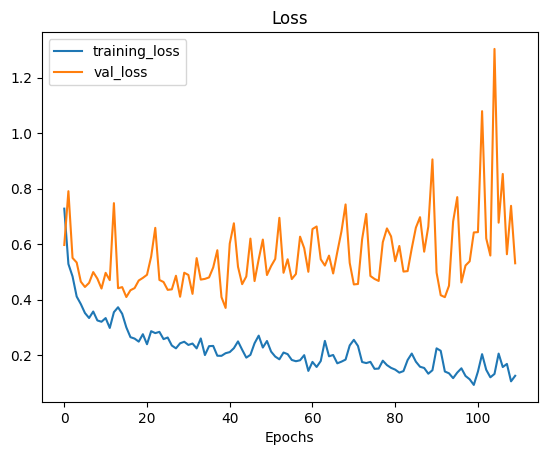

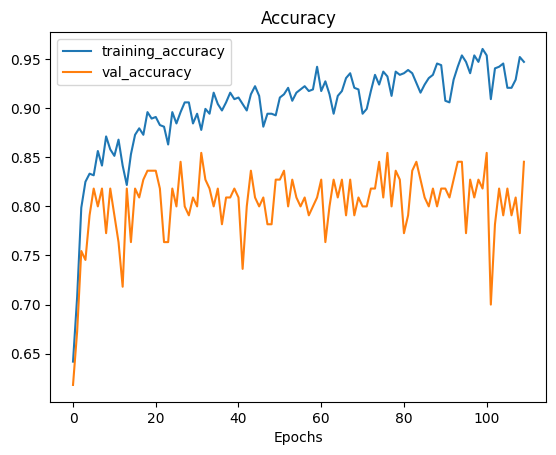

In [ ]:
tf.random.set_seed(42)

model_1 = Sequential([
    # Note the input shape is the desired size of the image 224 * 224 with 3 bytes color
    # This is the first convolution
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(2, 2),
    # The second convolution
    Conv2D(32, (3,3), activation='relu'),
    MaxPool2D(2,2),
    # The third convolution
    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    # Flatten the results to feed into a DNN
    Flatten(),
    # 512 neuron hidden layer
    Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('drones') and 1 for the other ('birds')
    Dense(1, activation='sigmoid')
])

model_1.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

callback = ModelCheckpoint(filepath=saved_models_path + "/model_1",
                           monitor="val_accuracy",
                           save_best_only=True,
                           mode="max")

history_1 = model_1.fit(train_data_augmented,
                    epochs=110,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data),
                    callbacks=[callback])

plot_loss_curves(history_1)

Epoch 1/120
19/19 [==============================] - ETA: 0s - loss: 0.7166 - accuracy: 0.5198

19/19 [==============================] - 28s 1s/step - loss: 0.7166 - accuracy: 0.5198 - val_loss: 0.6723 - val_accuracy: 0.6545
Epoch 2/120
19/19 [==============================] - ETA: 0s - loss: 0.5960 - accuracy: 0.6650

19/19 [==============================] - 19s 1s/step - loss: 0.5960 - accuracy: 0.6650 - val_loss: 0.7037 - val_accuracy: 0.6909
Epoch 3/120
19/19 [==============================] - 19s 1s/step - loss: 0.5650 - accuracy: 0.7393 - val_loss: 0.6645 - val_accuracy: 0.5545
Epoch 4/120
19/19 [==============================] - ETA: 0s - loss: 0.5793 - accuracy: 0.7525

19/19 [==============================] - 19s 1s/step - loss: 0.5793 - accuracy: 0.7525 - val_loss: 0.5929 - val_accuracy: 0.7091
Epoch 5/120
19/19 [==============================] - ETA: 0s - loss: 0.5378 - accuracy: 0.7558

19/19 [==============================] - 21s 1s/step - loss: 0.5378 - accuracy: 0.7558 - val_loss: 0.5997 - val_accuracy: 0.7182
Epoch 6/120
19/19 [==============================] - 18s 938ms/step - loss: 0.4809 - accuracy: 0.7855 - val_loss: 0.6476 - val_accuracy: 0.6909
Epoch 7/120
19/19 [==============================] - ETA: 0s - loss: 0.4528 - accuracy: 0.7987

...

19/19 [==============================] - 22s 1s/step - loss: 0.4338 - accuracy: 0.8102 - val_loss: 0.5097 - val_accuracy: 0.7636
Epoch 9/120
19/19 [==============================] - 18s 904ms/step - loss: 0.4353 - accuracy: 0.8036 - val_loss: 0.5129 - val_accuracy: 0.7273
Epoch 10/120
19/19 [==============================] - 17s 924ms/step - loss: 0.4280 - accuracy: 0.8069 - val_loss: 0.4949 - val_accuracy: 0.7182
Epoch 11/120
19/19 [==============================] - 19s 970ms/step - loss: 0.4242 - accuracy: 0.8284 - val_loss: 0.6159 - val_accuracy: 0.7273
Epoch 12/120
19/19 [==============================] - 18s 927ms/step - loss: 0.4238 - accuracy: 0.8086 - val_loss: 0.4554 - val_accuracy: 0.7636
Epoch 13/120
19/19 [==============================] - ETA: 0s - loss: 0.4284 - accuracy: 0.8020

19/19 [==============================] - 20s 1s/step - loss: 0.4284 - accuracy: 0.8020 - val_loss: 0.4940 - val_accuracy: 0.7909
Epoch 14/120
19/19 [==============================] - 20s 1s/step - loss: 0.3928 - accuracy: 0.8300 - val_loss: 0.4804 - val_accuracy: 0.7727
Epoch 15/120
19/19 [==============================] - 17s 933ms/step - loss: 0.3914 - accuracy: 0.8201 - val_loss: 0.5337 - val_accuracy: 0.7909
Epoch 16/120
19/19 [==============================] - 19s 1s/step - loss: 0.4076 - accuracy: 0.8284 - val_loss: 0.5121 - val_accuracy: 0.7727
Epoch 17/120
19/19 [==============================] - 17s 921ms/step - loss: 0.4347 - accuracy: 0.8135 - val_loss: 0.8497 - val_accuracy: 0.5364
Epoch 18/120
19/19 [==============================] - 18s 937ms/step - loss: 0.4837 - accuracy: 0.7756 - val_loss: 0.5436 - val_accuracy: 0.7000
Epoch 19/120
19/19 [==============================] - 18s 933ms/step - loss: 0.4384 - accuracy: 0.8102 - val_loss: 0.4964 - val_accuracy: 0.7364
Epoch 2

19/19 [==============================] - 22s 1s/step - loss: 0.3363 - accuracy: 0.8515 - val_loss: 0.4890 - val_accuracy: 0.8273
Epoch 47/120
19/19 [==============================] - 18s 934ms/step - loss: 0.3637 - accuracy: 0.8465 - val_loss: 0.5032 - val_accuracy: 0.7364
Epoch 48/120
19/19 [==============================] - 18s 937ms/step - loss: 0.3250 - accuracy: 0.8531 - val_loss: 0.5644 - val_accuracy: 0.7455
Epoch 49/120
19/19 [==============================] - 17s 917ms/step - loss: 0.3198 - accuracy: 0.8630 - val_loss: 0.5523 - val_accuracy: 0.7273
Epoch 50/120
19/19 [==============================] - 19s 1s/step - loss: 0.3129 - accuracy: 0.8779 - val_loss: 0.5871 - val_accuracy: 0.7545
Epoch 51/120
19/19 [==============================] - 17s 904ms/step - loss: 0.3252 - accuracy: 0.8663 - val_loss: 0.6031 - val_accuracy: 0.7455
Epoch 52/120
19/19 [==============================] - 17s 912ms/step - loss: 0.3208 - accuracy: 0.8647 - val_loss: 0.4847 - val_accuracy: 0.7636
Epoc

19/19 [==============================] - 21s 1s/step - loss: 0.1603 - accuracy: 0.9257 - val_loss: 0.5949 - val_accuracy: 0.8364
Epoch 95/120
19/19 [==============================] - 19s 1s/step - loss: 0.1652 - accuracy: 0.9208 - val_loss: 0.7839 - val_accuracy: 0.8273
Epoch 96/120
19/19 [==============================] - 17s 915ms/step - loss: 0.2232 - accuracy: 0.9059 - val_loss: 0.6395 - val_accuracy: 0.7909
Epoch 97/120
19/19 [==============================] - 17s 905ms/step - loss: 0.1617 - accuracy: 0.9307 - val_loss: 0.5097 - val_accuracy: 0.8091
Epoch 98/120
19/19 [==============================] - 17s 893ms/step - loss: 0.1807 - accuracy: 0.9290 - val_loss: 0.4228 - val_accuracy: 0.8364
Epoch 99/120
19/19 [==============================] - 17s 904ms/step - loss: 0.1278 - accuracy: 0.9538 - val_loss: 1.1299 - val_accuracy: 0.7727
Epoch 100/120
19/19 [==============================] - 19s 1s/step - loss: 0.2665 - accuracy: 0.8944 - val_loss: 0.4897 - val_accuracy: 0.7455
Epoch 

19/19 [==============================] - 22s 1s/step - loss: 0.1706 - accuracy: 0.9307 - val_loss: 0.4925 - val_accuracy: 0.8636
Epoch 114/120
19/19 [==============================] - 17s 918ms/step - loss: 0.1389 - accuracy: 0.9389 - val_loss: 0.4540 - val_accuracy: 0.8455
Epoch 115/120
19/19 [==============================] - 17s 908ms/step - loss: 0.1301 - accuracy: 0.9455 - val_loss: 0.6556 - val_accuracy: 0.8182
Epoch 116/120
19/19 [==============================] - 18s 944ms/step - loss: 0.1683 - accuracy: 0.9323 - val_loss: 0.5599 - val_accuracy: 0.7727
Epoch 117/120
19/19 [==============================] - 17s 892ms/step - loss: 0.1240 - accuracy: 0.9488 - val_loss: 0.5485 - val_accuracy: 0.8273
Epoch 118/120
19/19 [==============================] - 19s 992ms/step - loss: 0.1378 - accuracy: 0.9373 - val_loss: 0.4506 - val_accuracy: 0.8545
Epoch 119/120
19/19 [==============================] - 18s 980ms/step - loss: 0.1597 - accuracy: 0.9406 - val_loss: 0.6705 - val_accuracy: 0.

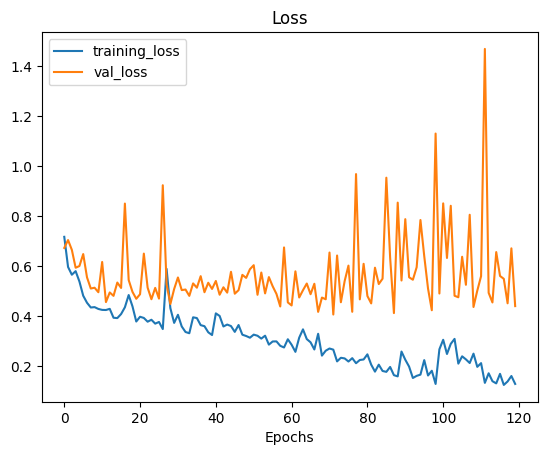

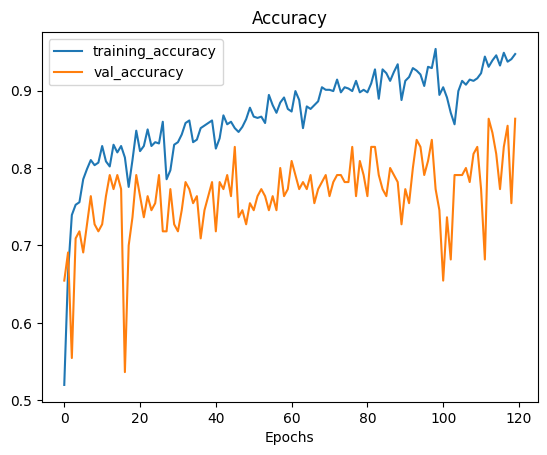

In [ ]:
tf.random.set_seed(42)

model_2 = Sequential([
    # Note the input shape is the desired size of the image 224 * 224 with 3 bytes color
    # This is the first convolution
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    Conv2D(16, (3,3), activation='relu'),
    MaxPool2D(2, 2),
    # The second convolution
    Conv2D(32, (3,3), activation='relu'),
    Conv2D(32, (3,3), activation='relu'),
    MaxPool2D(2,2),
    # The third convolution
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    # Flatten the results to feed into a DNN
    Flatten(),
    # 512 neuron hidden layer
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('drones') and 1 for the other ('birds')
    Dense(1, activation='sigmoid')
])

model_2.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

callback = ModelCheckpoint(filepath=saved_models_path + "/model_2",
                           monitor="val_accuracy",
                           save_best_only=True,
                           mode="max")

history_2 = model_2.fit(train_data_augmented,
                    epochs=120,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data),
                    callbacks=[callback])

plot_loss_curves(history_2)

Epoch 1/120
19/19 [==============================] - ETA: 0s - loss: 0.6980 - accuracy: 0.5347

19/19 [==============================] - 25s 1s/step - loss: 0.6980 - accuracy: 0.5347 - val_loss: 0.7132 - val_accuracy: 0.6818
Epoch 2/120
19/19 [==============================] - ETA: 0s - loss: 0.6149 - accuracy: 0.6584

19/19 [==============================] - 21s 1s/step - loss: 0.6149 - accuracy: 0.6584 - val_loss: 0.6545 - val_accuracy: 0.7727
Epoch 3/120
19/19 [==============================] - 17s 922ms/step - loss: 0.5273 - accuracy: 0.7508 - val_loss: 0.5510 - val_accuracy: 0.7182
Epoch 4/120
19/19 [==============================] - 17s 907ms/step - loss: 0.4684 - accuracy: 0.7888 - val_loss: 0.5184 - val_accuracy: 0.7364
Epoch 5/120
19/19 [==============================] - 19s 1s/step - loss: 0.5069 - accuracy: 0.7624 - val_loss: 0.5502 - val_accuracy: 0.7273
Epoch 6/120
19/19 [==============================] - 18s 968ms/step - loss: 0.4593 - accuracy: 0.7871 - val_loss: 0.6783 - val_accuracy: 0.7182
Epoch 7/120
19/19 [==============================] - 17s 912ms/step - loss: 0.4744 - accuracy: 0.7739 - val_loss: 0.5408 - val_accuracy: 0.7091
Epoch 8/120
19/19 [==============================] - 17s 894ms/step - loss: 0.4477 - accuracy: 0.7954 - val_loss: 0.4554 - val_accuracy: 0.7364
Epoch 9/12

19/19 [==============================] - 19s 1s/step - loss: 0.4262 - accuracy: 0.8069 - val_loss: 0.4581 - val_accuracy: 0.7818
Epoch 10/120
19/19 [==============================] - ETA: 0s - loss: 0.4240 - accuracy: 0.8086

19/19 [==============================] - 20s 1s/step - loss: 0.4240 - accuracy: 0.8086 - val_loss: 0.4381 - val_accuracy: 0.8091
Epoch 11/120
19/19 [==============================] - 17s 929ms/step - loss: 0.3953 - accuracy: 0.8251 - val_loss: 0.4420 - val_accuracy: 0.7909
Epoch 12/120
19/19 [==============================] - 18s 952ms/step - loss: 0.3762 - accuracy: 0.8300 - val_loss: 0.6643 - val_accuracy: 0.6727
Epoch 13/120
19/19 [==============================] - 18s 972ms/step - loss: 0.4480 - accuracy: 0.7970 - val_loss: 0.5202 - val_accuracy: 0.7636
Epoch 14/120
19/19 [==============================] - 17s 904ms/step - loss: 0.4027 - accuracy: 0.8201 - val_loss: 0.5913 - val_accuracy: 0.7273
Epoch 15/120
19/19 [==============================] - 19s 1s/step - loss: 0.3807 - accuracy: 0.8333 - val_loss: 0.5340 - val_accuracy: 0.7909
Epoch 16/120
19/19 [==============================] - 17s 893ms/step - loss: 0.3679 - accuracy: 0.8449 - val_loss: 0.5691 - val_accuracy: 0.7909
Epoc

19/19 [==============================] - 21s 1s/step - loss: 0.3599 - accuracy: 0.8482 - val_loss: 0.4130 - val_accuracy: 0.8273
Epoch 23/120
19/19 [==============================] - 17s 921ms/step - loss: 0.3620 - accuracy: 0.8350 - val_loss: 0.5186 - val_accuracy: 0.8273
Epoch 24/120
19/19 [==============================] - 18s 955ms/step - loss: 0.3482 - accuracy: 0.8614 - val_loss: 0.4791 - val_accuracy: 0.8091
Epoch 25/120
19/19 [==============================] - 17s 887ms/step - loss: 0.3357 - accuracy: 0.8680 - val_loss: 0.5402 - val_accuracy: 0.8000
Epoch 26/120
19/19 [==============================] - 17s 901ms/step - loss: 0.3443 - accuracy: 0.8531 - val_loss: 0.4764 - val_accuracy: 0.7545
Epoch 27/120
19/19 [==============================] - ETA: 0s - loss: 0.3907 - accuracy: 0.8366

19/19 [==============================] - 21s 1s/step - loss: 0.3907 - accuracy: 0.8366 - val_loss: 0.4080 - val_accuracy: 0.8455
Epoch 28/120
19/19 [==============================] - 17s 922ms/step - loss: 0.3270 - accuracy: 0.8531 - val_loss: 0.3558 - val_accuracy: 0.8182
Epoch 29/120
19/19 [==============================] - 20s 1s/step - loss: 0.3136 - accuracy: 0.8581 - val_loss: 0.4807 - val_accuracy: 0.8182
Epoch 30/120
19/19 [==============================] - 18s 901ms/step - loss: 0.3245 - accuracy: 0.8581 - val_loss: 0.4260 - val_accuracy: 0.7909
Epoch 31/120
19/19 [==============================] - 17s 906ms/step - loss: 0.2960 - accuracy: 0.8597 - val_loss: 0.4153 - val_accuracy: 0.8364
Epoch 32/120
19/19 [==============================] - 17s 880ms/step - loss: 0.2845 - accuracy: 0.8729 - val_loss: 0.5368 - val_accuracy: 0.7909
Epoch 33/120
19/19 [==============================] - ETA: 0s - loss: 0.3299 - accuracy: 0.8597

19/19 [==============================] - 20s 1s/step - loss: 0.3299 - accuracy: 0.8597 - val_loss: 0.4250 - val_accuracy: 0.8545
Epoch 34/120
19/19 [==============================] - 18s 924ms/step - loss: 0.3246 - accuracy: 0.8597 - val_loss: 0.5857 - val_accuracy: 0.8091
Epoch 35/120
19/19 [==============================] - 17s 896ms/step - loss: 0.3205 - accuracy: 0.8515 - val_loss: 0.4111 - val_accuracy: 0.8273
Epoch 36/120
19/19 [==============================] - ETA: 0s - loss: 0.3150 - accuracy: 0.8647

19/19 [==============================] - 19s 1s/step - loss: 0.3150 - accuracy: 0.8647 - val_loss: 0.3445 - val_accuracy: 0.8727
Epoch 37/120
19/19 [==============================] - 18s 941ms/step - loss: 0.3133 - accuracy: 0.8696 - val_loss: 0.3984 - val_accuracy: 0.8182
Epoch 38/120
19/19 [==============================] - 18s 945ms/step - loss: 0.3145 - accuracy: 0.8663 - val_loss: 0.3257 - val_accuracy: 0.8545
Epoch 39/120
19/19 [==============================] - 17s 893ms/step - loss: 0.3193 - accuracy: 0.8680 - val_loss: 0.3934 - val_accuracy: 0.8364
Epoch 40/120
19/19 [==============================] - 17s 900ms/step - loss: 0.2872 - accuracy: 0.8680 - val_loss: 0.4010 - val_accuracy: 0.8091
Epoch 41/120
19/19 [==============================] - 17s 906ms/step - loss: 0.2766 - accuracy: 0.8845 - val_loss: 0.3710 - val_accuracy: 0.8273
Epoch 42/120
19/19 [==============================] - 17s 894ms/step - loss: 0.3104 - accuracy: 0.8564 - val_loss: 0.6419 - val_accuracy: 0.8000
E

19/19 [==============================] - 20s 1s/step - loss: 0.0818 - accuracy: 0.9752 - val_loss: 0.4766 - val_accuracy: 0.8818
Epoch 109/120
19/19 [==============================] - 17s 917ms/step - loss: 0.0696 - accuracy: 0.9719 - val_loss: 0.7910 - val_accuracy: 0.8727
Epoch 110/120
19/19 [==============================] - 19s 954ms/step - loss: 0.0673 - accuracy: 0.9769 - val_loss: 0.4866 - val_accuracy: 0.8545
Epoch 111/120
19/19 [==============================] - 17s 907ms/step - loss: 0.1230 - accuracy: 0.9571 - val_loss: 0.8261 - val_accuracy: 0.8182
Epoch 112/120
19/19 [==============================] - 18s 962ms/step - loss: 0.1007 - accuracy: 0.9587 - val_loss: 0.7011 - val_accuracy: 0.8364
Epoch 113/120
19/19 [==============================] - 17s 897ms/step - loss: 0.1695 - accuracy: 0.9356 - val_loss: 0.4977 - val_accuracy: 0.8727
Epoch 114/120
19/19 [==============================] - 17s 900ms/step - loss: 0.0970 - accuracy: 0.9637 - val_loss: 1.1027 - val_accuracy: 0.

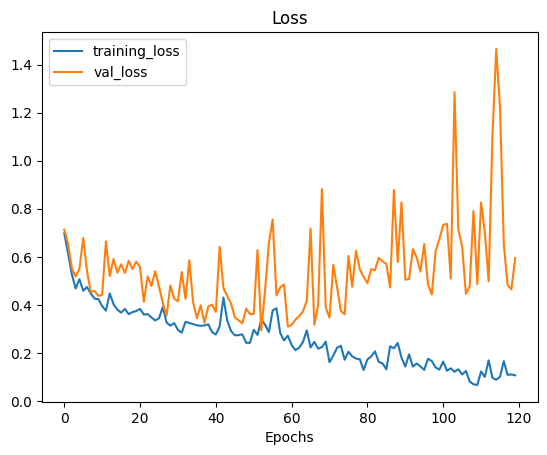

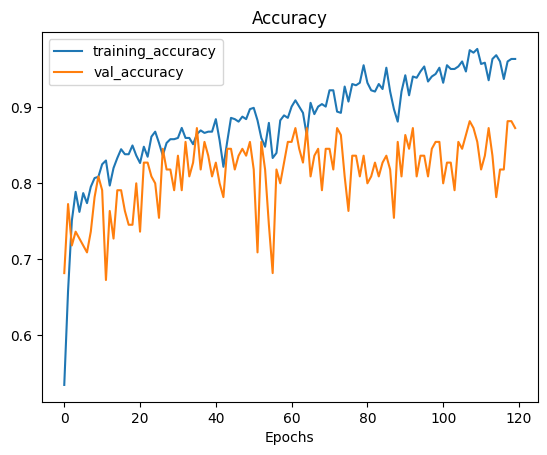

In [ ]:
tf.random.set_seed(42)

model_3 = Sequential([
    # Note the input shape is the desired size of the image 224 * 224 with 3 bytes color
    # This is the first convolution
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    Conv2D(16, (3,3), activation='relu'),
    MaxPool2D(2, 2),
    # The second convolution
    Conv2D(32, (4,4), activation='relu'),
    Conv2D(32, (4,4), activation='relu'),
    MaxPool2D(2,2),
    # The third convolution
    Conv2D(64, (5,5), activation='relu'),
    Conv2D(64, (5,5), activation='relu'),
    MaxPool2D(2,2),
    # Flatten the results to feed into a DNN
    Flatten(),
    # 512 neuron hidden layer
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('drones') and 1 for the other ('birds')
    Dense(1, activation='sigmoid')
])

model_3.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

callback = ModelCheckpoint(filepath=saved_models_path + "/model_3",
                           monitor="val_accuracy",
                           save_best_only=True,
                           mode="max")

history_3 = model_3.fit(train_data_augmented,
                    epochs=120,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data),
                    callbacks=[callback])

plot_loss_curves(history_3)

Epoch 1/150
19/19 [==============================] - ETA: 0s - loss: 0.6965 - accuracy: 0.5297

19/19 [==============================] - 22s 992ms/step - loss: 0.6965 - accuracy: 0.5297 - val_loss: 0.6626 - val_accuracy: 0.5818
Epoch 2/150
19/19 [==============================] - ETA: 0s - loss: 0.5446 - accuracy: 0.7327

19/19 [==============================] - 21s 1s/step - loss: 0.5446 - accuracy: 0.7327 - val_loss: 0.6973 - val_accuracy: 0.7182
Epoch 3/150
19/19 [==============================] - 17s 911ms/step - loss: 0.5514 - accuracy: 0.7343 - val_loss: 0.6394 - val_accuracy: 0.6727
Epoch 4/150
19/19 [==============================] - 18s 941ms/step - loss: 0.5012 - accuracy: 0.7822 - val_loss: 0.5353 - val_accuracy: 0.7182
Epoch 5/150
19/19 [==============================] - ETA: 0s - loss: 0.4914 - accuracy: 0.7855

19/19 [==============================] - 19s 1s/step - loss: 0.4914 - accuracy: 0.7855 - val_loss: 0.5216 - val_accuracy: 0.7364
Epoch 6/150
19/19 [==============================] - 17s 871ms/step - loss: 0.4494 - accuracy: 0.8053 - val_loss: 0.5400 - val_accuracy: 0.7364
Epoch 7/150
19/19 [==============================] - ETA: 0s - loss: 0.4291 - accuracy: 0.8317

19/19 [==============================] - 20s 1s/step - loss: 0.4291 - accuracy: 0.8317 - val_loss: 0.4787 - val_accuracy: 0.7727
Epoch 8/150
19/19 [==============================] - ETA: 0s - loss: 0.4253 - accuracy: 0.8300

19/19 [==============================] - 19s 1s/step - loss: 0.4253 - accuracy: 0.8300 - val_loss: 0.5102 - val_accuracy: 0.7818
Epoch 9/150
19/19 [==============================] - ETA: 0s - loss: 0.4405 - accuracy: 0.8102

19/19 [==============================] - 20s 1s/step - loss: 0.4405 - accuracy: 0.8102 - val_loss: 0.4547 - val_accuracy: 0.8091
Epoch 10/150
19/19 [==============================] - 17s 890ms/step - loss: 0.3873 - accuracy: 0.8350 - val_loss: 0.5960 - val_accuracy: 0.7273
Epoch 11/150
19/19 [==============================] - 18s 901ms/step - loss: 0.3798 - accuracy: 0.8449 - val_loss: 0.4533 - val_accuracy: 0.7818
Epoch 12/150
19/19 [==============================] - 18s 956ms/step - loss: 0.4010 - accuracy: 0.8251 - val_loss: 0.4926 - val_accuracy: 0.8091
Epoch 13/150
19/19 [==============================] - ETA: 0s - loss: 0.4498 - accuracy: 0.7921

19/19 [==============================] - 19s 1s/step - loss: 0.4498 - accuracy: 0.7921 - val_loss: 0.4501 - val_accuracy: 0.8182
Epoch 14/150
19/19 [==============================] - ETA: 0s - loss: 0.3862 - accuracy: 0.8284

19/19 [==============================] - 20s 1s/step - loss: 0.3862 - accuracy: 0.8284 - val_loss: 0.4192 - val_accuracy: 0.8455
Epoch 15/150
19/19 [==============================] - 17s 863ms/step - loss: 0.3807 - accuracy: 0.8333 - val_loss: 0.4557 - val_accuracy: 0.8091
Epoch 16/150
19/19 [==============================] - 17s 898ms/step - loss: 0.3391 - accuracy: 0.8498 - val_loss: 0.4129 - val_accuracy: 0.8273
Epoch 17/150
19/19 [==============================] - 17s 886ms/step - loss: 0.3294 - accuracy: 0.8548 - val_loss: 0.4609 - val_accuracy: 0.7636
Epoch 18/150
19/19 [==============================] - 17s 870ms/step - loss: 0.3753 - accuracy: 0.8416 - val_loss: 0.4790 - val_accuracy: 0.7727
Epoch 19/150
19/19 [==============================] - 17s 891ms/step - loss: 0.3650 - accuracy: 0.8581 - val_loss: 0.4064 - val_accuracy: 0.7909
Epoch 20/150
19/19 [==============================] - 17s 880ms/step - loss: 0.3551 - accuracy: 0.8350 - val_loss: 0.4782 - val_accuracy: 0.7909
E

19/19 [==============================] - 21s 1s/step - loss: 0.1715 - accuracy: 0.9290 - val_loss: 0.9270 - val_accuracy: 0.8636
Epoch 89/150
19/19 [==============================] - 18s 940ms/step - loss: 0.1586 - accuracy: 0.9554 - val_loss: 0.9511 - val_accuracy: 0.8000
Epoch 90/150
19/19 [==============================] - 18s 917ms/step - loss: 0.1666 - accuracy: 0.9439 - val_loss: 1.0616 - val_accuracy: 0.7727
Epoch 91/150
19/19 [==============================] - 17s 883ms/step - loss: 0.1375 - accuracy: 0.9488 - val_loss: 0.8362 - val_accuracy: 0.8455
Epoch 92/150
19/19 [==============================] - 17s 915ms/step - loss: 0.1378 - accuracy: 0.9521 - val_loss: 0.6136 - val_accuracy: 0.8091
Epoch 93/150
19/19 [==============================] - 17s 892ms/step - loss: 0.1571 - accuracy: 0.9422 - val_loss: 0.6204 - val_accuracy: 0.8273
Epoch 94/150
19/19 [==============================] - 17s 930ms/step - loss: 0.1716 - accuracy: 0.9356 - val_loss: 1.0773 - val_accuracy: 0.8182
E

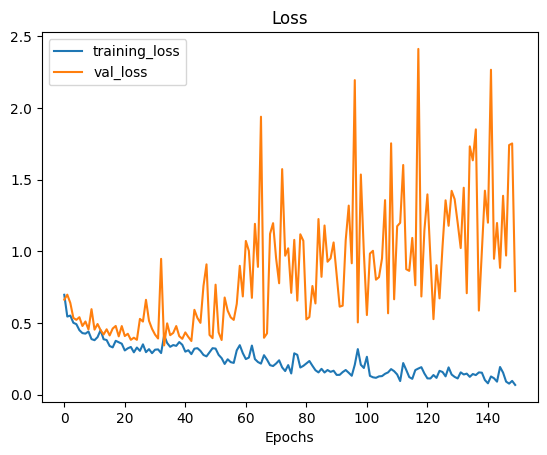

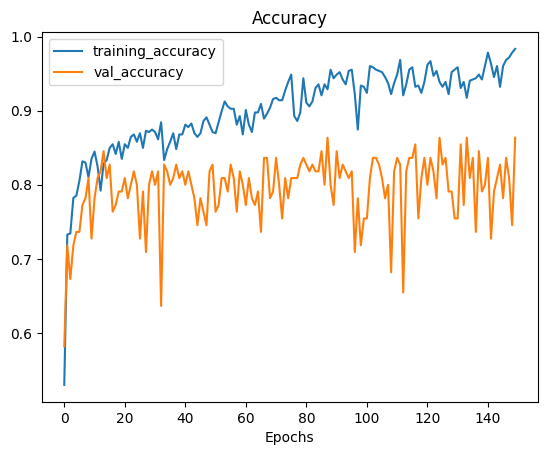

In [ ]:
tf.random.set_seed(42)

model_4 = Sequential([
    # Note the input shape is the desired size of the image 224 * 224 with 3 bytes color
    # This is the first convolution
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    Conv2D(16, (3,3), activation='relu'),
    MaxPool2D(2,2),
    # The second convolution
    Conv2D(32, (4,4), activation='relu'),
    Conv2D(32, (4,4), activation='relu'),
    MaxPool2D(2,2),
    # The third convolution
    Conv2D(64, (5,5), activation='relu'),
    Conv2D(64, (5,5), activation='relu'),
    MaxPool2D(2,2),
    # Flatten the results to feed into a DNN
    Flatten(),
    # 512 neuron hidden layer
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('drones') and 1 for the other ('birds')
    Dense(1, activation='sigmoid')
])

model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

callback = ModelCheckpoint(filepath=saved_models_path + "/model_4",
                           monitor="val_accuracy",
                           save_best_only=True,
                           mode="max")

history_4 = model_4.fit(train_data_augmented,
                    epochs=150,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data),
                    callbacks=[callback])

plot_loss_curves(history_4)

## 9.10 Load the saved model

In [ ]:
saved_model = load_model(saved_models_path + "/model_2")

In [ ]:
saved_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 222, 222, 16)      448       
                                                                 
 conv2d_16 (Conv2D)          (None, 220, 220, 16)      2320      
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 110, 110, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 108, 108, 32)      4640      
                                                                 
 conv2d_18 (Conv2D)          (None, 106, 106, 32)      9248      
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 53, 53, 32)        0         
 ng2D)                                                

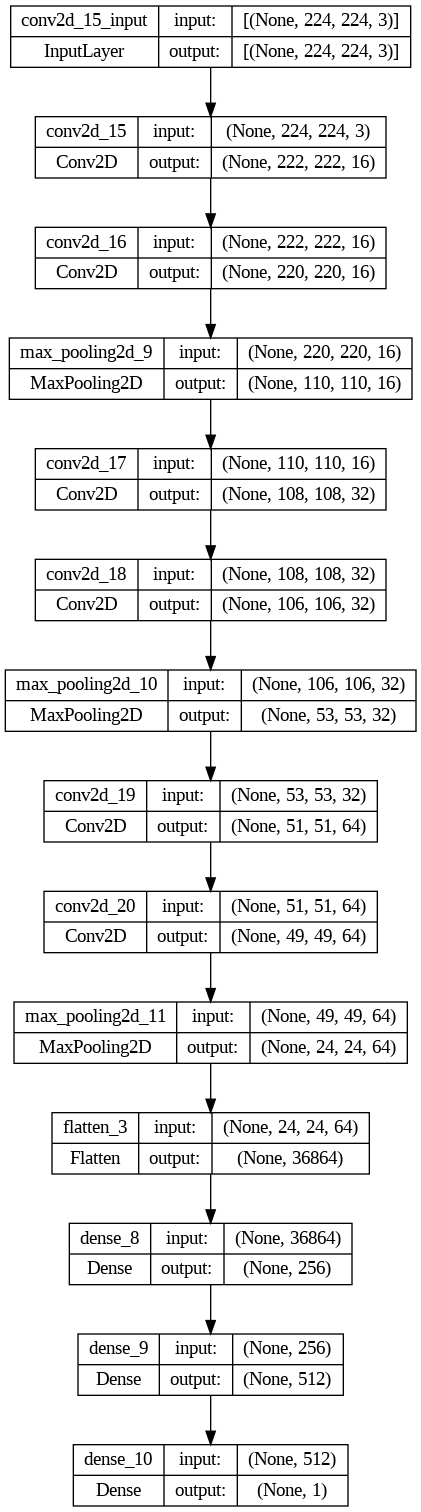

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(saved_model, show_shapes=True)

## 9.11 Evaluate on training data, augmented training data and test data

In [ ]:
saved_model.evaluate(train_data)

19/19 [==============================] - 431s 24s/step - loss: 0.1402 - accuracy: 0.9340


[0.14015105366706848, 0.933993399143219]

In [ ]:
saved_model.evaluate(train_data_augmented)

In [ ]:
saved_model.evaluate(test_data)

4/4 [==============================] - 24s 8s/step - loss: 0.3178 - accuracy: 0.8818


[0.31776538491249084, 0.8818181753158569]

## 9.12 Evaluate on custom images over the web


In [ ]:
custom_birds = "/content/drive/MyDrive/custom_test/birds"
custom_drones = "/content/drive/MyDrive/custom_test/drones"

birds_images = os.listdir(custom_birds)
drones_images = os.listdir(custom_drones)

In [ ]:
walk_through_dir(custom_birds)

There are 0 directories and 1 images in '/content/drive/MyDrive/custom_test/birds'.


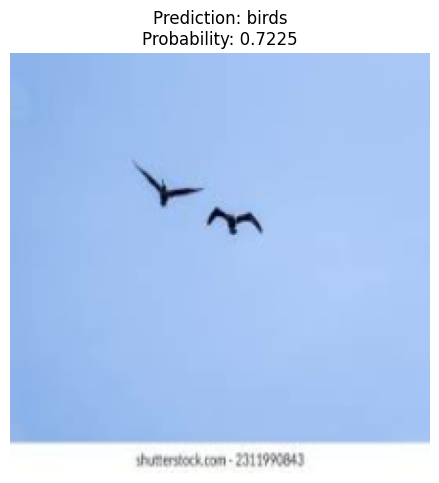

In [ ]:
pred_and_plot_directory(saved_model, custom_birds)

In [ ]:
walk_through_dir(custom_drones)

There are 0 directories and 1 images in '/content/drive/MyDrive/custom_test/drones'.


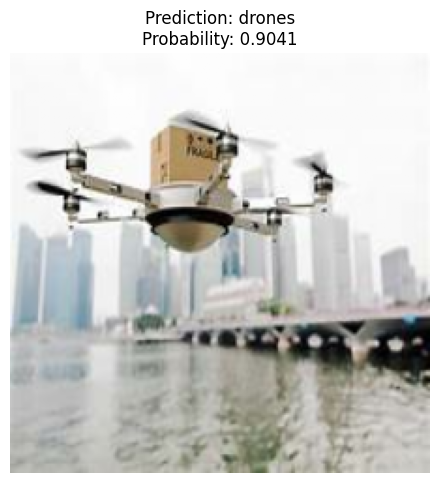

In [ ]:
pred_and_plot_directory(saved_model, custom_drones)